In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, 
                              f1_score, accuracy_score, roc_curve, roc_auc_score,
                              precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

np.random.seed(42)

In [2]:
titanic = pd.read_csv('../data/processed/titanic_cleaned.csv')

features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
X = titanic[features].copy()
X['Sex'] = (titanic['Sex'] == 'female').astype(int)  # encode Sex
y = titanic['Survived'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Class distribution:\n", y.value_counts(normalize=True))

Class distribution:
 Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [3]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print(f"\nTN={tn}, FP={fp}, FN={fn}, TP={tp}")

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
specificity = tn / (tn + fp)

print(f"\nPrecision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Specificity: {specificity:.4f}")

Confusion Matrix:
[[95 15]
 [20 49]]

TN=95, FP=15, FN=20, TP=49

Precision: 0.7656
Recall (Sensitivity): 0.7101
F1 Score: 0.7368
Specificity: 0.8636


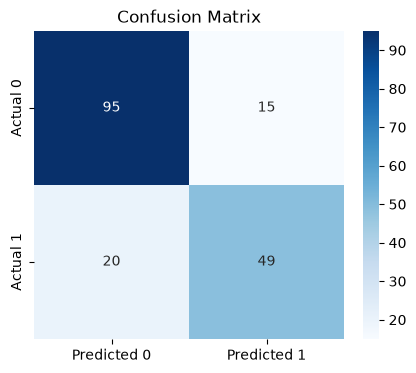

In [4]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.show()

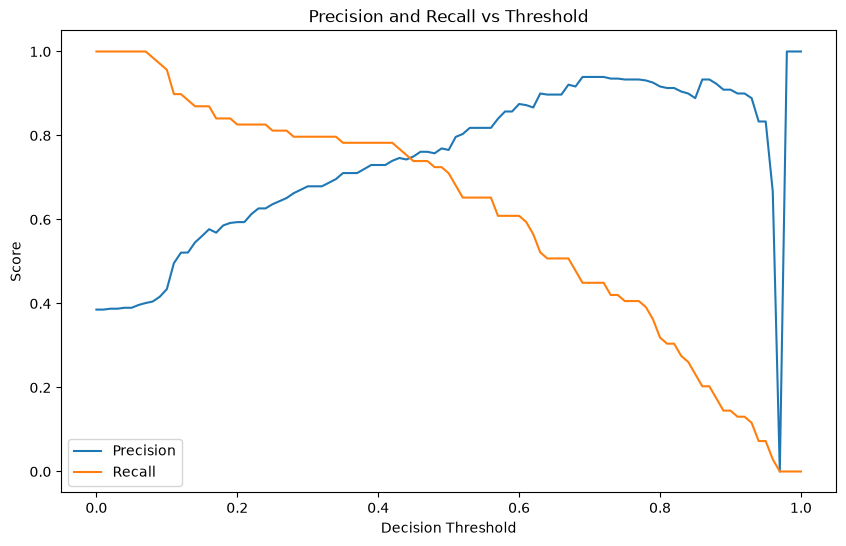

In [5]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.0, 1.01, 0.01)
precisions, recalls = [], []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    if y_pred_t.sum() == 0:
        precisions.append(1.0)  # no positive predictions -> precision undefined, treat as 1
    else:
        precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision and Recall vs Threshold')
plt.show()

## Choosing a Threshold for Two Business Scenarios

**Scenario A: Missing a survivor prediction is costly** (e.g., we 
want to make sure we don't overlook anyone who could survive — 
prioritise recall). We would choose a **lower threshold** (e.g., 
0.3), accepting more false positives to catch more true positives.

**Scenario B: False alarms are costly** (e.g., a resource-limited 
intervention where wrongly flagging someone wastes resources — 
prioritise precision). We would choose a **higher threshold** 
(e.g., 0.7), accepting that we may miss some true positives but 
reducing wasted effort on false positives.

Looking at the chart, at threshold=0.3, recall is high but precision 
drops. At threshold=0.7, precision improves but recall drops 
significantly. The right choice depends entirely on which type of 
error costs more in the specific business context.

In [6]:
# Create a synthetic imbalanced version for demonstration (90% negative, 10% positive)
from sklearn.datasets import make_classification

X_imb, y_imb = make_classification(n_samples=2000, n_features=10, 
                                     weights=[0.9, 0.1], random_state=42)
X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

model_imb = LogisticRegression()
model_imb.fit(X_train_imb, y_train_imb)
y_proba_imb = model_imb.predict_proba(X_test_imb)[:, 1]

print("Class balance:", np.bincount(y_imb))

Class balance: [1795  205]


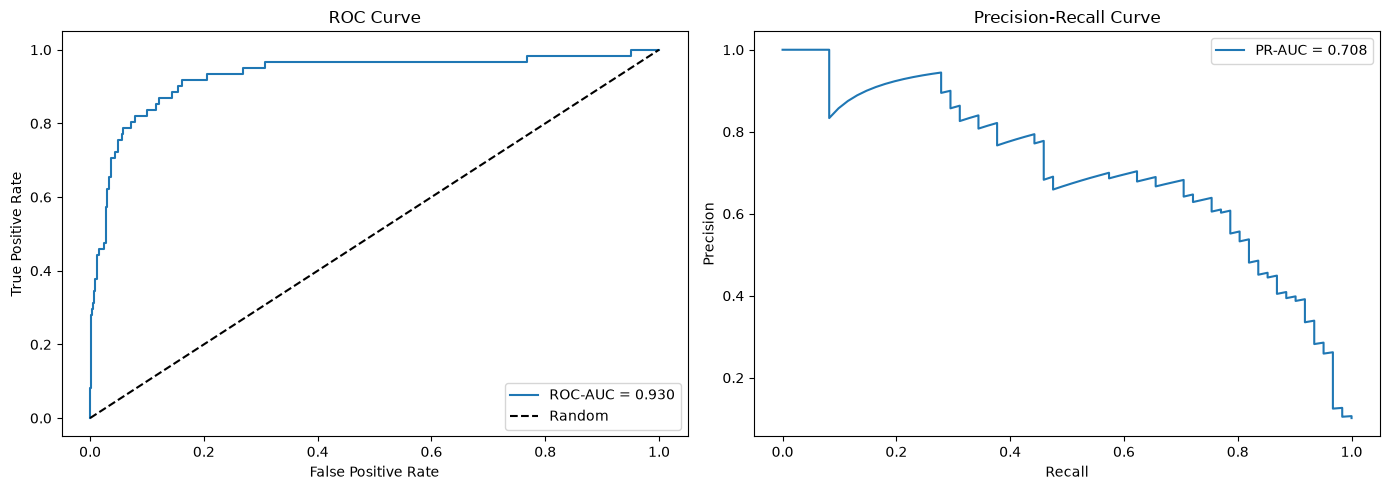

In [7]:
fpr, tpr, _ = roc_curve(y_test_imb, y_proba_imb)
roc_auc = roc_auc_score(y_test_imb, y_proba_imb)

precision_curve, recall_curve, _ = precision_recall_curve(y_test_imb, y_proba_imb)
pr_auc = average_precision_score(y_test_imb, y_proba_imb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, label=f'PR-AUC = {pr_auc:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## Why ROC-AUC Can Look Optimistic on Imbalanced Data

ROC-AUC uses the False Positive Rate, which is FP / (FP + TN). 
When negatives vastly outnumber positives (like our 90/10 split), 
the TN count is huge, so even a large number of false positives 
barely moves the FPR — making the ROC curve look good even when 
precision is actually poor.

PR-AUC instead uses Precision, which is TP / (TP + FP) — it 
directly reflects how many of our positive predictions are 
correct, without being diluted by the large number of true 
negatives. This is why PR curves are more informative than ROC 
curves on imbalanced datasets: they expose problems that ROC-AUC 
can hide.

In [8]:
baseline_model = LogisticRegression()
baseline_model.fit(X_train_imb, y_train_imb)
baseline_proba = baseline_model.predict_proba(X_test_imb)[:, 1]
baseline_pr_auc = average_precision_score(y_test_imb, baseline_proba)
print(f"Baseline PR-AUC: {baseline_pr_auc:.4f}")

Baseline PR-AUC: 0.7079


In [9]:
weighted_model = LogisticRegression(class_weight='balanced')
weighted_model.fit(X_train_imb, y_train_imb)
weighted_proba = weighted_model.predict_proba(X_test_imb)[:, 1]
weighted_pr_auc = average_precision_score(y_test_imb, weighted_proba)
print(f"Class-weighted PR-AUC: {weighted_pr_auc:.4f}")

Class-weighted PR-AUC: 0.6858


In [10]:
undersampler = RandomUnderSampler(random_state=42)
X_under, y_under = undersampler.fit_resample(X_train_imb, y_train_imb)

under_model = LogisticRegression()
under_model.fit(X_under, y_under)
under_proba = under_model.predict_proba(X_test_imb)[:, 1]
under_pr_auc = average_precision_score(y_test_imb, under_proba)
print(f"Undersampling PR-AUC: {under_pr_auc:.4f}")

Undersampling PR-AUC: 0.6720


In [11]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_imb, y_train_imb)

smote_model = LogisticRegression()
smote_model.fit(X_smote, y_smote)
smote_proba = smote_model.predict_proba(X_test_imb)[:, 1]
smote_pr_auc = average_precision_score(y_test_imb, smote_proba)
print(f"SMOTE PR-AUC: {smote_pr_auc:.4f}")

SMOTE PR-AUC: 0.6828


          method    PR-AUC
0       Baseline  0.707859
1   Class Weight  0.685790
2  Undersampling  0.671981
3          SMOTE  0.682819


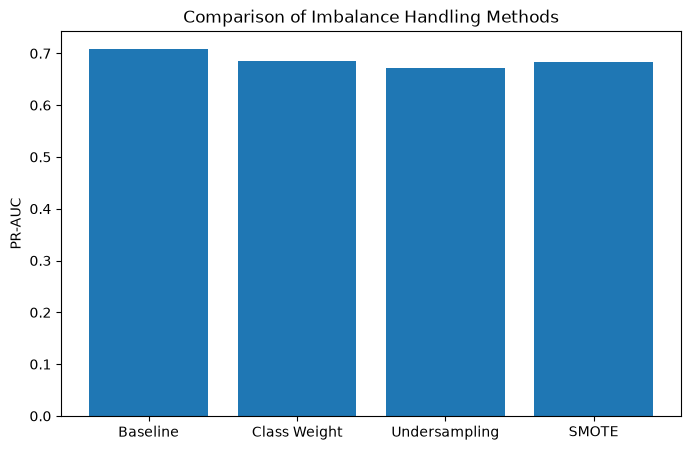

In [12]:
comparison = pd.DataFrame({
    'method': ['Baseline', 'Class Weight', 'Undersampling', 'SMOTE'],
    'PR-AUC': [baseline_pr_auc, weighted_pr_auc, under_pr_auc, smote_pr_auc]
})
print(comparison)

plt.figure(figsize=(8, 5))
plt.bar(comparison['method'], comparison['PR-AUC'])
plt.ylabel('PR-AUC')
plt.title('Comparison of Imbalance Handling Methods')
plt.show()

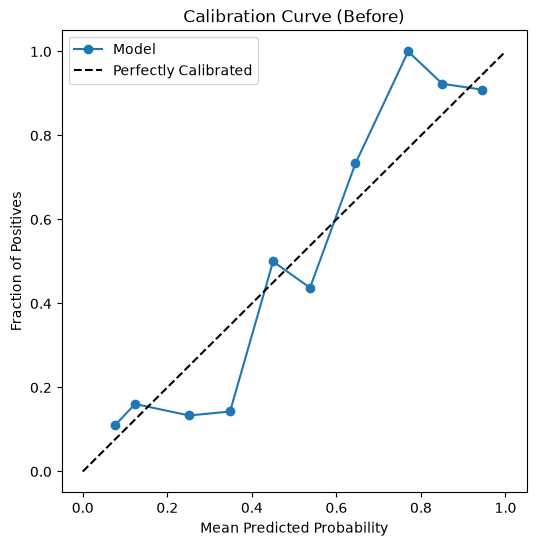

In [13]:
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Before)')
plt.legend()
plt.show()

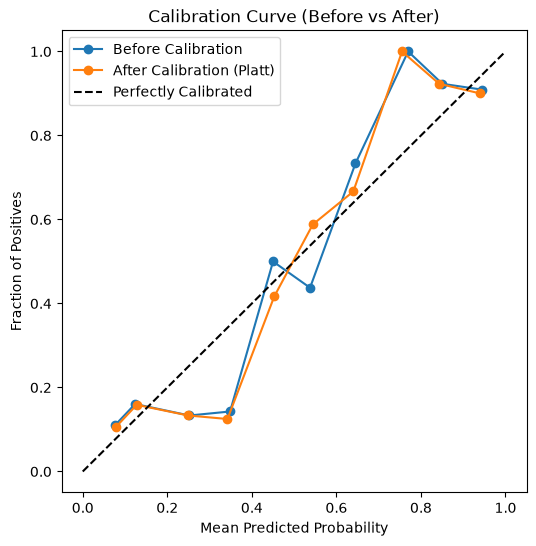

In [14]:
calibrated_model = CalibratedClassifierCV(model, method='sigmoid', cv=5)
calibrated_model.fit(X_train_scaled, y_train)
y_proba_calibrated = calibrated_model.predict_proba(X_test_scaled)[:, 1]

prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_proba_calibrated, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Before Calibration')
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label='After Calibration (Platt)')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Before vs After)')
plt.legend()
plt.show()

In [15]:
from sklearn.metrics import f1_score
from sklearn.datasets import load_iris

iris = load_iris()
X_iris, y_iris = iris.data, iris.target

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42
)

multi_model = LogisticRegression(max_iter=1000)
multi_model.fit(X_train_i, y_train_i)
y_pred_i = multi_model.predict(X_test_i)

macro_f1 = f1_score(y_test_i, y_pred_i, average='macro')
weighted_f1 = f1_score(y_test_i, y_pred_i, average='weighted')

print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

Macro F1: 1.0000
Weighted F1: 1.0000


## Macro vs Weighted F1

Macro F1 treats every class equally regardless of size — it 
averages the F1 score of each class without weighting by how many 
samples belong to that class. This is useful when all classes 
matter equally, even rare ones.

Weighted F1 averages F1 scores weighted by the number of true 
instances of each class — larger classes have more influence on 
the final score. This is useful when overall performance across 
the actual class distribution matters more than treating every 
class equally.